In [1]:
from accuracy_functions import (
    loop_accuracy_calculations,
)
from visualization import (
    bulk_vs_singlecell_matrix_viz,
    super_plot_heatmaps_pseudobulk,
    heatmap_plot_accuracy_metrics_pseudobulk,
    heatmap_plot_accuracy_metrics_pseudobulk_rd0,
    super_plot_heatmaps_fixed_rd_pseudobulk,
    heatmap_plot_accuracy_metrics_pseudobulk_rd0_ncells500k
)

In [2]:
DATA_PATH = "../../data/output_data/vcf_update" # Path to the directory containing the data files
FIGURES_PATH = "../../data/figures/" # Path to the directory where the figures will be saved

In [3]:
# Generally all the combinations of these parameters are present in the data, 
# except for BAMixChecker which only has results for read depth 0.
# And occassionally, tools may be missing results because they failed to run for certain combinations of parameters.
tools = ["CrosscheckFingerprints", "HYSYS", "NGSCheckmate", "Vireo"]
ncells_list = [10000, 50000, 100000, 500000]
read_depths = [0, 1, 10, 20, 30, 40]
datasets = ["hgsoc", "high_grade_glioma", "low_grade_glioma", "wilms_tumor"]

# Individual heatmaps

Heatmaps of sample similarity between two sets of pseudobulks. 

To repeat this for all of our pseudobulk datasets loop over all the tools, ncells_list (=number of cells included in a pseudobulk), read_depths, and datasets listed above.

In [4]:
# bulk_vs_singlecell_matrix_viz(
#     DATA_PATH=DATA_PATH,
#     pseudobulk=True,
#     tool="Vireo",
#     dataset="high_grade_glioma",
#     ncells=500000,
#     rd=0,
#     mod1="_1", # only pseudobulks from set 1 on the y-axis
#     mod2="_2", # only pseudobulks from set 2 on the x-axis
#     save_fig=False,
#     FIGURES_PATH=FIGURES_PATH,
# )

# Heatmap grids

Combining sample similarity heatmaps into a grid to assess the impact of the read depth filter and the number of cells in pseudobulks. The colorbar is not shown, but it is shared between all the subplots.

This can be repeated for the tools and datasets listed above.

In [4]:
# Plot A of pseudobulk plot

super_plot_heatmaps_fixed_rd_pseudobulk(
    DATA_PATH=DATA_PATH,
    FIGURES_PATH=FIGURES_PATH,
    tools=tools,
    dataset="high_grade_glioma",
    ncells_list=ncells_list,
    rd=0,
    experiment="basic",
    save_fig=True,
)

Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 0...
Processing tool HYSYS, dataset high_grade_glioma, read depth 0...
Processing tool NGSCheckmate, dataset high_grade_glioma, read depth 0...
Processing tool Vireo, dataset high_grade_glioma, read depth 0...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 0...
Processing tool HYSYS, dataset high_grade_glioma, read depth 0...
Processing tool NGSCheckmate, dataset high_grade_glioma, read depth 0...
Processing tool Vireo, dataset high_grade_glioma, read depth 0...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 0...
Processing tool HYSYS, dataset high_grade_glioma, read depth 0...
Processing tool NGSCheckmate, dataset high_grade_glioma, read depth 0...
Processing tool Vireo, dataset high_grade_glioma, read depth 0...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 0...
Processing tool HYSYS, dataset high_grade_glioma, rea

/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Processing tool CrosscheckFingerprints, dataset hgsoc, read depth 0...
Processing tool HYSYS, dataset hgsoc, read depth 0...
Processing tool NGSCheckmate, dataset hgsoc, read depth 0...
Processing tool Vireo, dataset hgsoc, read depth 0...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 0...
Processing tool HYSYS, dataset high_grade_glioma, read depth 0...
Processing tool NGSCheckmate, dataset high_grade_glioma, read depth 0...
Processing tool Vireo, dataset high_grade_glioma, read depth 0...
Processing tool CrosscheckFingerprints, dataset low_grade_glioma, read depth 0...
Processing tool HYSYS, dataset low_grade_glioma, read depth 0...
Processing tool NGSCheckmate, dataset low_grade_glioma, read depth 0...
Processing tool Vireo, dataset low_grade_glioma, read depth 0...
Processing tool CrosscheckFingerprints, dataset wilms_tumor, read depth 0...
Processing tool HYSYS, dataset wilms_tumor, read depth 0...
Processing tool NGSCheckmate, dataset wilms_tumor, 

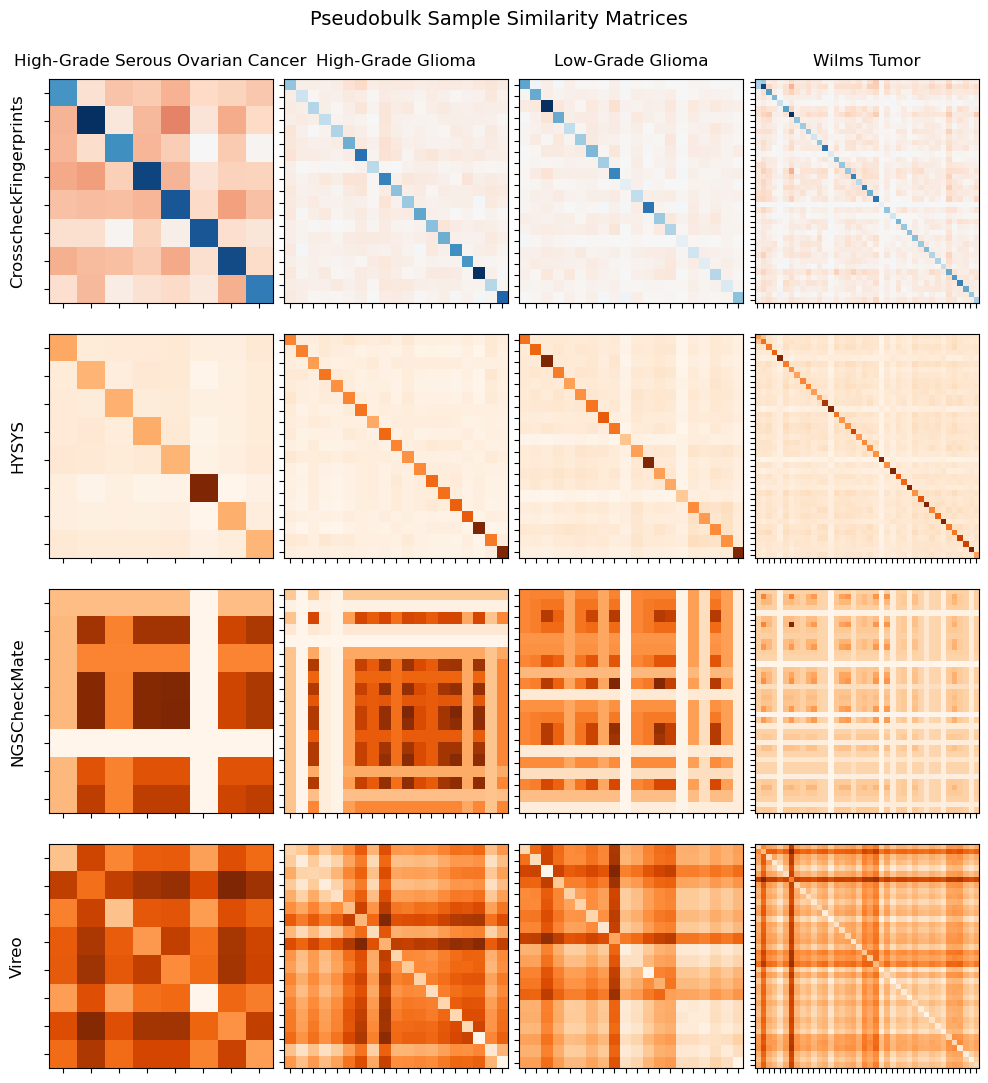

In [5]:
super_plot_heatmaps_pseudobulk(
    DATA_PATH=DATA_PATH, 
    FIGURES_PATH=FIGURES_PATH, 
    tools=tools, 
    datasets=datasets, 
    ncells=500000, 
    rd=0,
    experiment="basic", 
    save_fig=True,
)

# Accuracy plots 

In these pseudobulk experiments we know for certain which pseudobulks were drawn from the same samples. 
I.e. we know the ground truth of which pseudobulks should match and which should not match. 

We calculate and visualize the following metrics: 
- fraction_inconclusive (fraction of sample matches that a tool could not classify as match or non-match)
- accuracy
- balanced_accuracy
- precision
- recall
- f1

In [4]:
# Do the accuracy calculations for all the tools, datasets, ncells, and read depths listed
# and save the results in a dataframe
# Any data files that are missing will be skipped and the accuracy metrics for those combinations are not included in the dataframe
df = loop_accuracy_calculations(
    DATA_PATH=DATA_PATH,
    experiment="pseudobulk",
    tools=tools,
    datasets=datasets,
    ncells_list=[500000],
    read_depths=[0],
)

/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was 

Collapsing duplicate Vireo row labels for dataset=low_grade_glioma, pseudobulk=True, ncells=500000, rd=0: ['pseudobulk_n_barcodes_500000_1', 'pseudobulk_n_barcodes_500000_2']
Collapsing duplicate Vireo column labels for dataset=low_grade_glioma, pseudobulk=True, ncells=500000, rd=0: ['pseudobulk_n_barcodes_500000_1', 'pseudobulk_n_barcodes_500000_2']


/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [5]:
df

,tool,pseudobulk,dataset,ncells,read depth,fraction_inconclusive,accuracy,balanced_accuracy,precision,recall,f1
0,CrosscheckFingerprints,True,high_grade_glioma,500000,0,0.000000,0.980609,0.989766,0.730769,1.000,0.844444
1,CrosscheckFingerprints,True,hgsoc,500000,0,0.000000,0.984375,0.991071,0.888889,1.000,0.941176
2,CrosscheckFingerprints,True,low_grade_glioma,500000,0,0.000000,0.000000,0.000000,0.000000,0.000,0.000000
3,CrosscheckFingerprints,True,wilms_tumor,500000,0,0.000000,0.930000,0.964103,0.263158,1.000,0.416667
4,HYSYS,True,high_grade_glioma,500000,0,0.000000,1.000000,1.000000,1.000000,1.000,1.000000
5,HYSYS,True,hgsoc,500000,0,0.109375,0.890625,0.562500,1.000000,0.125,0.222222
6,HYSYS,True,low_grade_glioma,500000,0,0.000000,1.000000,1.000000,1.000000,1.000,1.000000
7,HYSYS,True,wilms_tumor,500000,0,0.003125,1.000000,1.000000,1.000000,1.000,1.000000
8,NGSCheckmate,True,high_grade_glioma,500000,0,0.000000,1.000000,1.000000,1.000000,1.000,1.000000
9,NGSCheckmate,True,hgsoc,500000,0,0.000000,1.000000,1.000000,1.000000,1.000,1.000000


In [ ]:
# A grid of 4 plots: one for each tool (excluding BAMixChecker).
# Each plot shows an accuracy metric for all combinations of ncells and read depths.
# This can be repeated for all datasets and accuracy metrics listed above.
heatmap_plot_accuracy_metrics_pseudobulk(
    df=df, 
    dataset="high_grade_glioma", 
    metric="f1", # options: "fraction_inconclusive", "accuracy", "balanced_accuracy", "precision", "recall", "f1"
    save_fig=False, 
    FIGURES_PATH=FIGURES_PATH,
)

In [ ]:
# A grid of 4 plots, each for a different accuracy metric (fraction_inconclusive, f1, precision, recall).
# Each plot shows an accuracy metric for all tools and ncells. 
# Read depth is fixed at 0.
# This can be repeated for all datasets listed above.

heatmap_plot_accuracy_metrics_pseudobulk_rd0(
    df=df, 
    dataset="high_grade_glioma", 
    save_fig=True, 
    FIGURES_PATH=FIGURES_PATH,
)

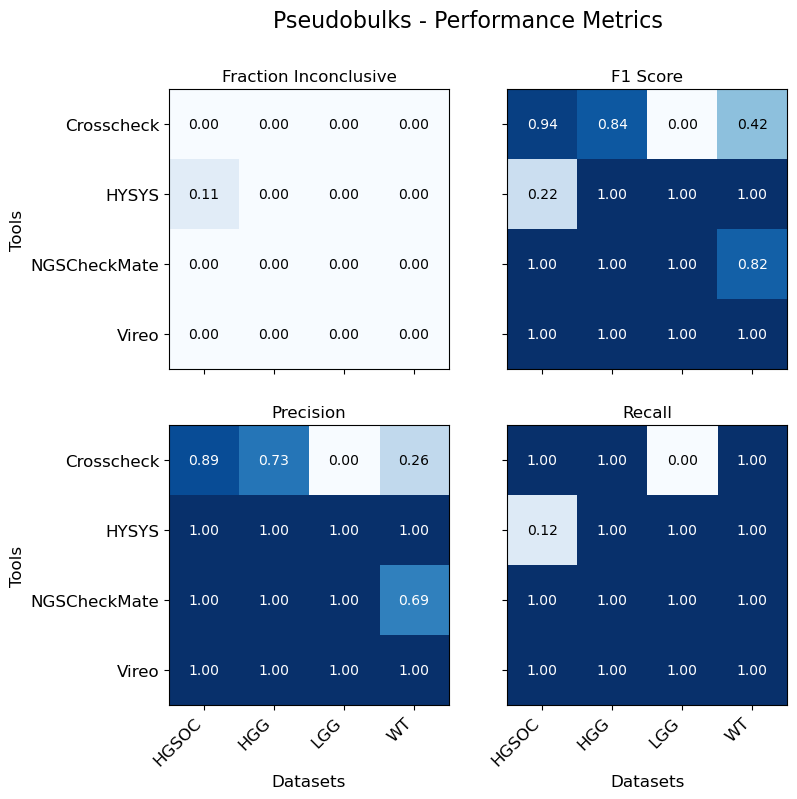

In [7]:
# Part B of pseudobulk plot
heatmap_plot_accuracy_metrics_pseudobulk_rd0_ncells500k(
    df, 
    save_fig=True, 
    FIGURES_PATH=FIGURES_PATH
)

# Conclusions

- Vireo performs best across a range pseudobulk sizes. 
- HYSYS has similar performance for the biggest pseudobulks we tested. 
- BAMixChecker is probably not working correctly since it always says that nothing matches each other. Notably, "inconclusives" in BAMixChecker are indistinguishable in the results from non-matches.
- CrosscheckFingerprints and NGSCheckMate perform pretty poorly. They tend to have decent recall for big pseudbulks, but poor precision. I.e. They call more matches than there really are (lots of false positives, few false negatives.)
- The read depth filter cut-off has little effect here, presumably because the pseudobulks are drawn from the same samples (same modality, average read depth, etc).
- As expected, more data (=bigger pseudobulks) leads to better results.